CLASSIFICATION AND NEURAL NETWROKS IN MACHINE LEARNING

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
data={
    "Hours_Studied": [1,2,3,4,5,6,7,8,2,6,7,3],
    "Attendance":    [50,55,60,65,70,80,85,90,40,75,88,58],
    "Result":        [0,0,0,0,1,1,1,1,0,1,1,0]   #0:Fail / 1:Pass
}
df=pd.DataFrame(data)
df

,Hours_Studied,Attendance,Result
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,0
4,5,70,1
5,6,80,1
6,7,85,1
7,8,90,1
8,2,40,0
9,6,75,1


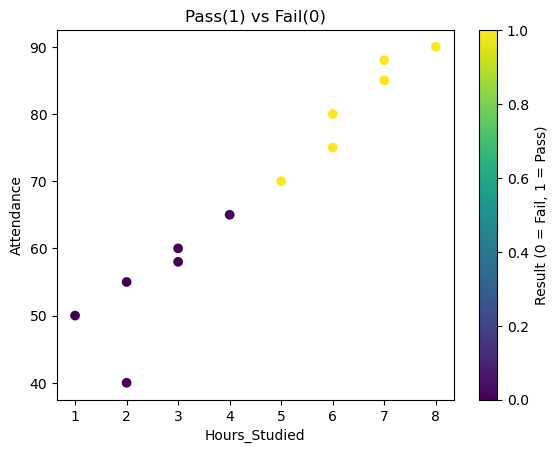

In [7]:
plt.scatter(df["Hours_Studied"], df["Attendance"], c=df["Result"])
plt.xlabel("Hours_Studied")
plt.ylabel("Attendance")
plt.title("Pass(1) vs Fail(0)")

plt.colorbar(label="Result (0 = Fail, 1 = Pass)")
plt.show()



In [8]:
X=df[["Hours_Studied", "Attendance"]]
Y=df["Result"]

In [10]:
model=LogisticRegression()
model.fit(X,Y)

LogisticRegression()

In [11]:
predictions=model.predict(X)
predictions

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0], dtype=int64)

In [14]:
n_stu=pd.DataFrame({
    "Hours_Studied":[5],
    "Attendance":[75]
})
model.predict(n_stu)

array([1], dtype=int64)

In [15]:
print(model.classes_)

[0 1]


In [18]:
model.predict_proba(n_stu)


array([[0.00407951, 0.99592049]])

In [19]:
accuracy=accuracy_score(Y, predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


In [21]:
cm=confusion_matrix(Y, predictions)
print(cm)

[[6 0]
 [0 6]]


In [23]:
pip install pytorch


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for pytorch
Failed to build pytorch
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [6 lines of output]
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 34, in <module>
    File "C:\Users\shama\AppData\Local\Temp\pip-install-0ncl2_5f\pytorch_3f38232f7fab487dbd0c8c9ceadce6c9\setup.py", line 15, in <module>
      raise Exception(message)
  Exception: You tried to install "pytorch". The package named for PyTorch is "torch"
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pytorch
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pytorch)


In [24]:
%pip install torch torchvision torchaudio



  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
    --------------------------------------- 2.4/113.8 MB 44.6 MB/s eta 0:00:03
   - -------------------------------------- 3.4/113.8 MB 9.2 MB/s eta 0:00:13
   - -------------------------------------- 3.4/113.8 MB 9.2 MB/s eta 0:00:13
   - -------------------------------------- 3.9/113.8 MB 4.4 MB/s eta 0:00:26
   - -------------------------------------- 5.0/113.8 MB 4.6 MB/s eta 0:00:24
   - -------------------------------------- 5.5/113.8 MB 4.4 MB/s eta 0:00:25
   -- ------------------------------------- 6.3/113.8 MB 4.1 MB/s eta 0:00:27
   -- ------------------------------------- 7.9/113.8 MB 4.5 MB/s eta 0:00:24
   --- ------------------------------------ 8.7/113.8 MB 4.5 MB/s eta 0:00:24
   --- ------------------------------------ 9.4/113.8 MB 4.4 MB/s eta 0:00:24
   --- ------------------------------------ 10.5/113.8 MB 4.4 MB/s eta 0:00:24
   ---

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim


In [26]:
X=torch.tensor([
    [1.0],[2.0],[3.0],[4.0],
    [5.0],[6.0],[7.0],[8.0]
])
y=torch.tensor([
    [0.0],[0.0],[0.0],[0.0],
    [1.0],[1.0],[1.0],[1.0]
])

PART 1- SINGLE LAYER PERCEPTON(SLP)

In [27]:
model=nn.Sequential(
    nn.Linear(1,1),
    nn.Sigmoid()
)

In [28]:
criterion=nn.BCELoss()
optimizer=optim.SGD(model.parameters(), lr=0.1)

In [34]:
for epoch in range(20000):
    y_pred=model(X)
    loss=criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("Training complete")

Training complete


In [35]:
test=torch.tensor([[6.0]])
prediction=model(test)
print(f"Pass probability: {prediction.item()}")

Pass probability: 0.9999998807907104


PART 2 - MULTI-LAYER PERCEPTON(MLP)

In [36]:
mlp=nn.Sequential(
    nn.Linear(1,5),
    nn.ReLU(),
    nn.Linear(5,1),
    nn.Sigmoid()
)

In [41]:
optimizer=optim.SGD(mlp.parameters(), lr=0.1)
for epoch in range(20000):
    y_pred=mlp(X)
    loss=criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("MLP training done")

MLP training done


In [42]:
prediction=mlp(test)
print(f"MLP pass probability: {prediction.item()}")

MLP pass probability: 1.0


In [13]:
from sklearn import datasets
iris=datasets.load_iris()


In [2]:
print(dir(iris))
print(iris.feature_names)
print(iris.target)
print(iris.target_names)

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [4]:
X, y=iris.data, iris.target

In [5]:
print(X.shape, y.shape)

(150, 4) (150,)


In [6]:
from sklearn.model_selection import train_test_split
#default split: 0.5/0.5
Xtrain, Xtest, ytrain, ytest=train_test_split(X, y, random_state=1, train_size=0.5)
print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, ytest.shape)

(75, 4) (75,)
(75, 4) (75,)


In [7]:
from sklearn.neighbors import KNeighborsClassifier     #import classifier
model=KNeighborsClassifier(n_neighbors=3)              #initializing classifier
model.fit(Xtrain, ytrain)                              #training
y_hat=model.predict(Xtest)                             #prediction
from sklearn.metrics import accuracy_score             #evaluation
accuracy_score(ytest, y_hat)

0.92

Multinomial logistic regression accuracy: 0.9666666666666667
One-vs-Rest logistic regression accuracy: 0.9166666666666666


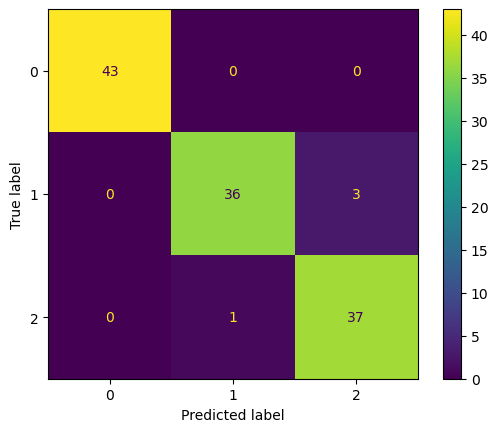

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=42, train_size=0.2)
multi_logreg=LogisticRegression()
multi_logreg.fit(X_train, y_train)                #compute w
ovr_logreg=OneVsRestClassifier(LogisticRegression())
ovr_logreg.fit(X_train, y_train)

y_pred_multi=multi_logreg.predict(X_test)
y_pred_ovr=ovr_logreg.predict(X_test)
print('Multinomial logistic regression accuracy:', accuracy_score(y_test, y_pred_multi))
print('One-vs-Rest logistic regression accuracy:', accuracy_score(y_test, y_pred_ovr))
conf_mat_multi=confusion_matrix(y_test, y_pred_multi)
conf_mat_ovr=confusion_matrix(y_test, y_pred_ovr)
disp=ConfusionMatrixDisplay(confusion_matrix=conf_mat_multi)
disp.plot()
plt.show()

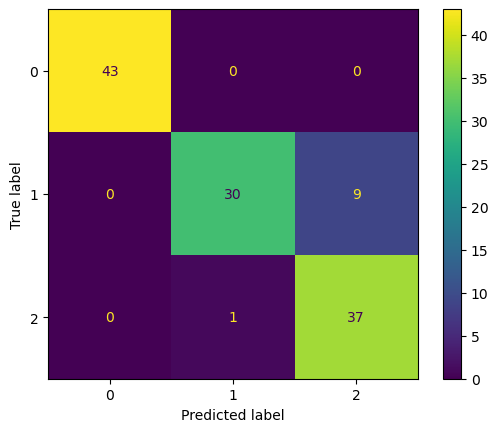

In [11]:
disp=ConfusionMatrixDisplay(confusion_matrix=conf_mat_ovr)
disp.plot()
plt.show()